In [2]:
#  Licensed under the Apache License, Version 2.0 (the "License");
#  you may not use this file except in compliance with the License.
#  You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
#  Unless required by applicable law or agreed to in writing, software
#  distributed under the License is distributed on an "AS IS" BASIS,
#  WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
#  See the License for the specific language governing permissions and
#  limitations under the License.
#
#   Authored by:  Tommi Heikkilä (LUT),
#
#   Edited by: Laura Murgatroyd (STFC-UKRI)

# Napari + CIL showcase
CIL User Meeting 2026

## Summary

We would like to easily transfer data in CIL DataContainers (namely AcquisitionData and ImageData) to the visualization software [Napari](https://napari.org/stable/index.html). Luckily Napari can be called from Python scripts and Jupyter notebooks.

Let's try loading the familiar [walnut data](https://zenodo.org/records/4822516) and then look at it in Napari. The data even comes with a high resolution (FDK) reconstruction so we can load that instead of running a reconstruction code of our own.

## Licensing

- These codes are released under the Apache-2.0 license
- Napari is licensed under BSD-3-Clause license
- Walnut data is licensed under CC-4.0 license
- CIL is licensed under Apache-2.0 license

# Requirements
- This notebook was created and run using CIL version 25.0.0
- Napari must be installed to run this notebook. We installed using conda, with instructions found at: https://napari.org/dev/getting_started/installation.html 
- We used napari version 0.6.1

In [1]:
import cil
print(f"Using CIL version {cil.__version__}")

Using CIL version 25.0.0


In [4]:
import napari
print(f"Using napari version {napari.__version__}")

Using napari version 0.6.1


In [2]:
path = '../../data/walnut/valnut'

# remove some annoying warnings
import logging
logger = logging.getLogger('dxchange')
logger.setLevel(logging.ERROR)

import os
from cil.io import ZEISSDataReader, TIFFStackReader
from cil.processors import TransmissionAbsorptionConverter, Slicer
from cil.utilities.display import show2D, show_geometry
from cil.utilities.jupyter import islicer, link_islicer
from cil.framework import ImageGeometry

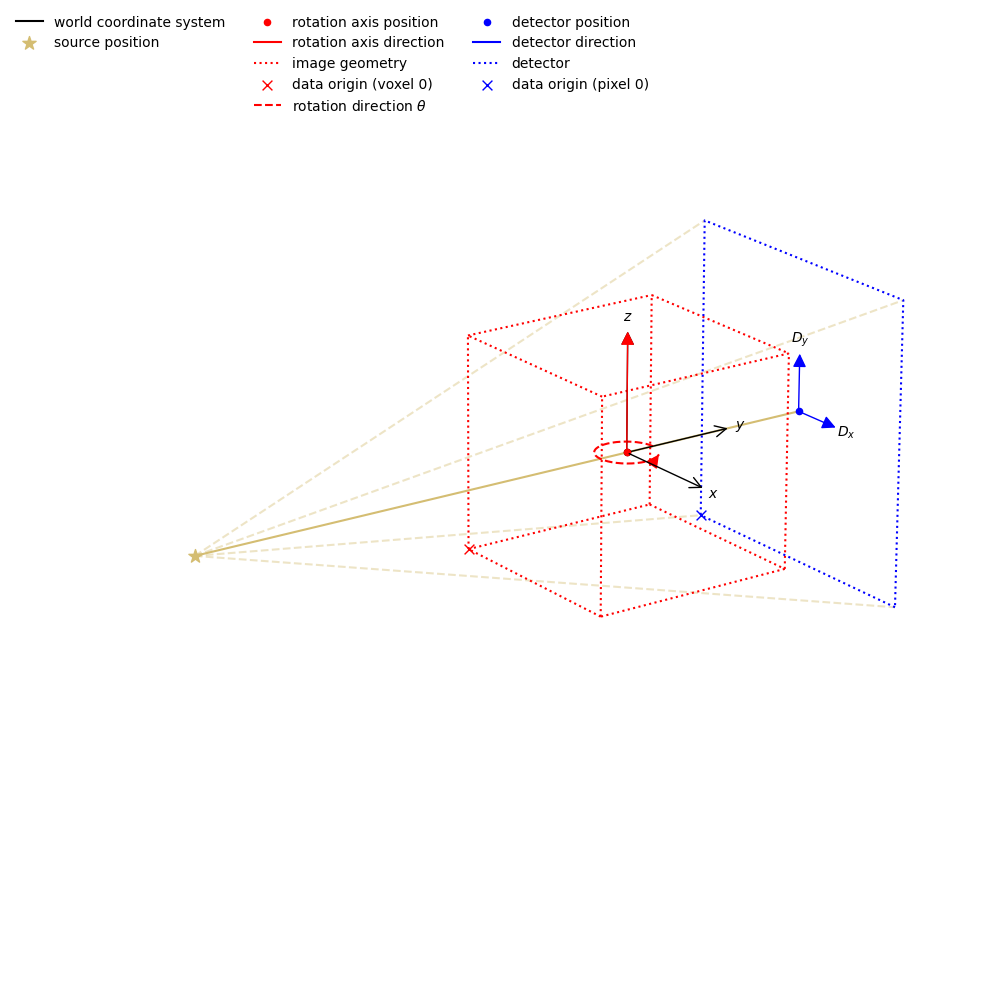

In [3]:
filename = os.path.join(path, "valnut_2014-03-21_643_28/tomo-A/valnut_tomo-A.txrm")

data = ZEISSDataReader(file_name=filename).read()
data.geometry.config.units = 'mm'
show_geometry(data.geometry)

In [4]:
data = TransmissionAbsorptionConverter()(data)

In [5]:
data = Slicer(roi={'angle': (0, -1, 2), 'vertical': (0, -1, 2), 'horizontal': (128, -129, 2)})(data)

New geometry:  3D Cone-beam tomography
System configuration:
	Source position: [   0.        , -105.05081177,    0.        ]
	Rotation axis position: [0., 0., 0.]
	Rotation axis direction: [0., 0., 1.]
	Detector position: [-3.29271477e-02,  4.50875740e+01, -3.29271477e-02]
	Detector direction x: [1., 0., 0.]
	Detector direction y: [0., 0., 1.]
Panel configuration:
	Number of pixels: [384 512]
	Pixel size: [0.13170859 0.13170859]
	Pixel origin: bottom-left
Channel configuration:
	Number of channels: 1
Acquisition description:
	Number of positions: 800
	Angles 0-9 in radians: [-3.1415665, -3.1337626, -3.125836 , -3.1180956, -3.1101887, -3.1022923,
 -3.0944946, -3.0865552, -3.0787866, -3.0708766]
	Angles 790-799 in radians: [3.0630383, 3.0709803, 3.0787284, 3.0866063, 3.0945296, 3.1023333,
 3.1101599, 3.117992 , 3.1258695, 3.1337383]
	Full angular array can be accessed with acquisition_data.geometry.angles
Distances in units: mm
Shape out:  (800, 512, 384)
New geometry shape:  (800, 512, 

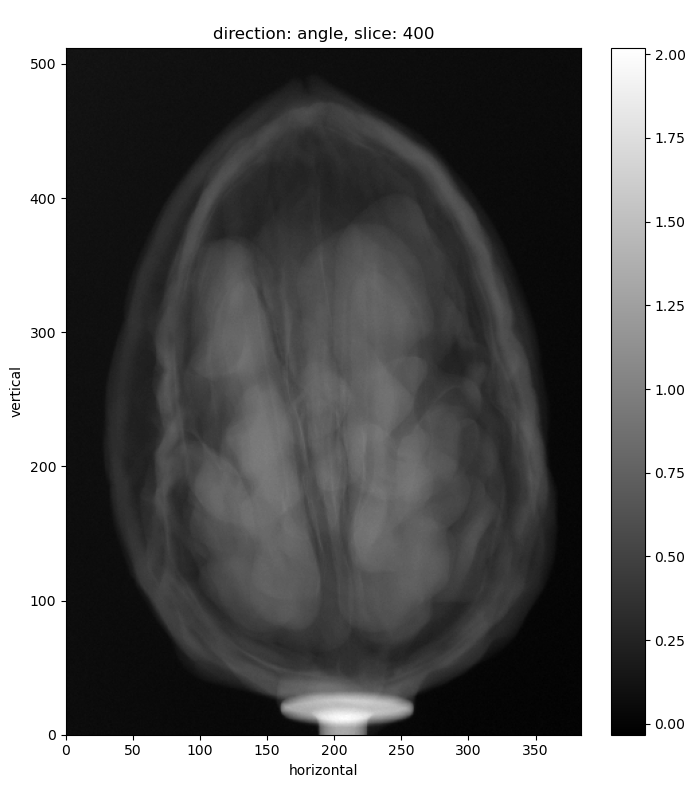

In [6]:
show2D(data)

In [7]:
data.as_array().shape

(800, 512, 384)

### Load the existing reconstruction as a tiff stack

In [8]:
mag = data.geometry.magnification
pixel_size = [data.geometry.pixel_size_h, data.geometry.pixel_size_v]

In [9]:
filename = os.path.join(path, "valnut_2014-03-21_643_28/tomo-A/recon")
ig = ImageGeometry(voxel_num_x=500, voxel_num_y=500, voxel_num_z=500, voxel_size_x=pixel_size[0]/mag, voxel_size_y=pixel_size[0]/mag, voxel_size_z=pixel_size[1]/mag)
recon = TIFFStackReader(file_name=filename, roi={'axis_0': (1, -2, 2), 'axis_1': (11, -12, 2), 'axis_2': (1, -2, 2)}).read_as_ImageData(ig)

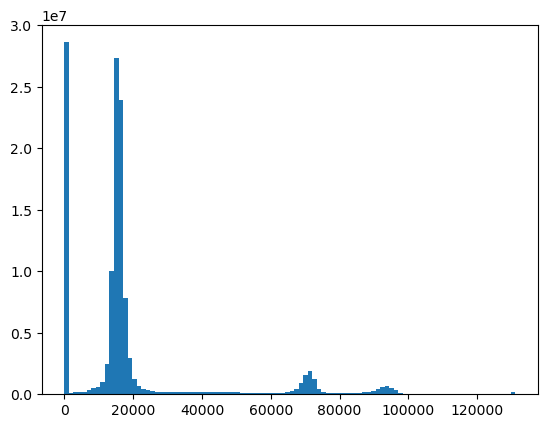

In [10]:
import matplotlib.pyplot as plt
plt.hist(recon.as_array().flatten(), bins=100)
plt.show()

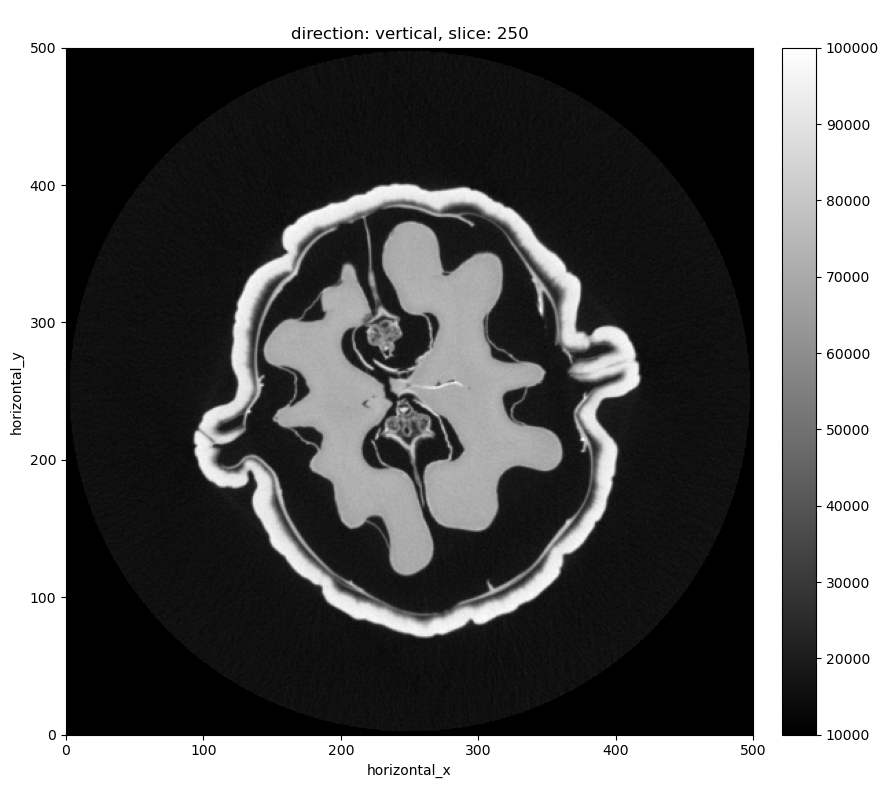

(500, 500, 500)


In [11]:
show2D(recon, fix_range=(10000, 100000))
print(recon.shape)

In [12]:
print(recon.geometry)

Number of channels: 1
channel_spacing: 1.0
voxel_num : x500,y500,z500
voxel_size : x0.09215560913085936,y0.09215560913085936,z0.09215560913085936
center : x0,y0,z0



## Go to Napari

We could just load the numpy array to Napari...

In [13]:
V = napari.Viewer()
V.add_image(recon.as_array())

<Image layer 'Image' at 0x18f96d138c0>

...but that doesn't have all the extra information such as the geometry and dimensions, which the full DataContainer has (at least should have. Turns out, `ImageGeometry` doesn't actually know the units...).

Luckily we can call this handy self-made viewer which takes some of the extra information and gives it to Napari. It should also take the same optional keyword arguments as the `napari.Viewer.add_image`

In [14]:
from napari_utils import napari_viewer

NV = napari_viewer()
NV.add_datacontainer(data, name="acquisition data", rendering="mip", opacity=0.5)

There is even a fancier version which automatically splits the data based on the given threshold values (either actual values or relative ratios).

In [15]:
NV2 = napari_viewer()
NV2.add_separated_datacontainer(recon, thresholds=[0.3, 0.6], style="ratio", name="fdk volume", rendering="mip", opacity=0.5, contrast_limits=[10000, 100000])